# Modeling



Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Loading and preparing data

In [4]:
disease = pd.read_csv("../data/raw/complete_plant_disease_database.csv")
climate = pd.read_csv("../data/raw/complete_plant_study_climate_data.csv")

df = disease.merge(climate, left_on="Obs", right_on="obs")

# basic cleaning
df = df.dropna(subset=["Incidence", "bio01", "bio12"])

# features + target
X = df[["bio01", "bio12"]]
y = df["Incidence"]

Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Decission Tree 

In [23]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Evaluate

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

print("Decision Tree:")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree:
MSE: 0.053224935507356116
R2: 0.22816500598591094


Random Forest

In [7]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Nueral Network

Scale Features

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training (small scale)

In [13]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(32, 16),   
    activation="relu",
    solver="adam",
    alpha=1e-4,                   
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,          
    n_iter_no_change=20
)

nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)

Evaluting same metrics as others

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("Neural Network:")
print("MSE:", mean_squared_error(y_test, y_pred_nn))
print("R2:", r2_score(y_test, y_pred_nn))

Neural Network:
MSE: 0.05388145049404384
R2: 0.21864463295041436


Predicted vs Actual plot

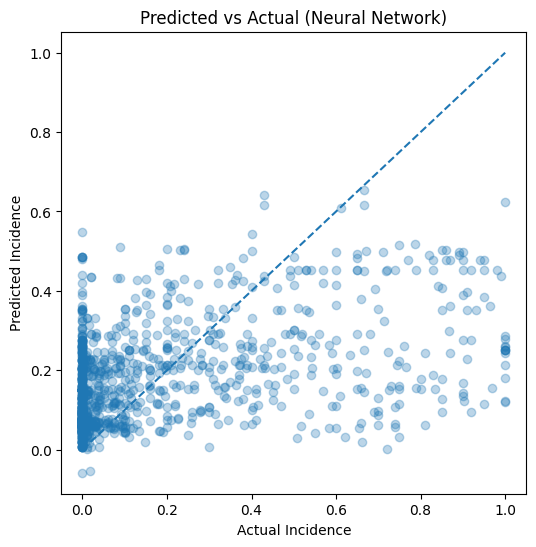

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_nn, alpha=0.3)
plt.plot([0,1], [0,1], '--')
plt.xlabel("Actual Incidence")
plt.ylabel("Predicted Incidence")
plt.title("Predicted vs Actual (Neural Network)")
plt.show()

Clustering

Preparing features

In [16]:
from sklearn.preprocessing import StandardScaler

cluster_features = df[["bio01", "bio12", "Incidence"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

Choosing number of clusters

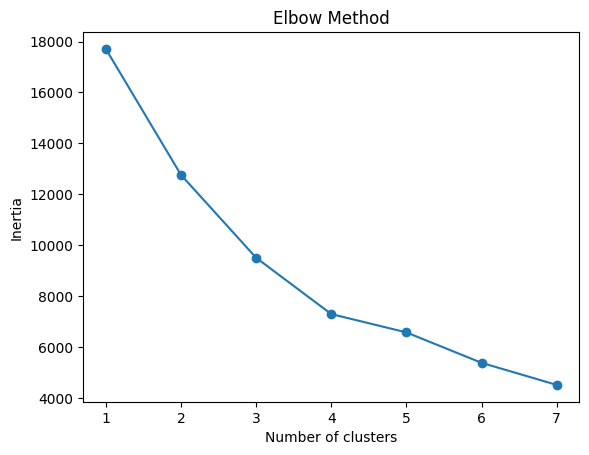

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,8), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Fitting Model

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

cluster_features["Cluster"] = clusters

Final Clustering Model

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

cluster_features["Cluster"] = clusters

Visualize clusters

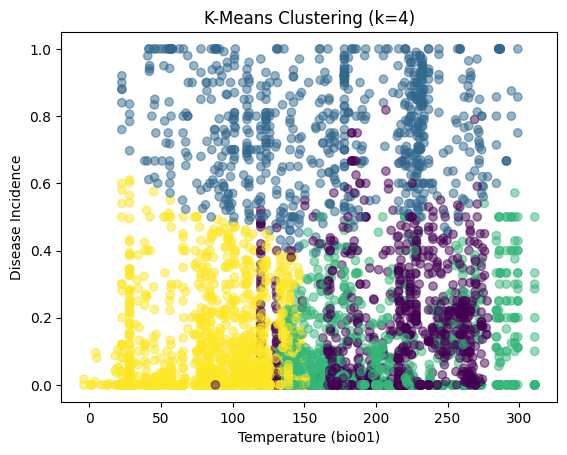

In [22]:
plt.scatter(
    cluster_features["bio01"],
    cluster_features["Incidence"],
    c=cluster_features["Cluster"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("Temperature (bio01)")
plt.ylabel("Disease Incidence")
plt.title("K-Means Clustering (k=4)")
plt.show()

Evaluation

In [8]:
# Linear Regression
print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

# Random Forest
print("\nRandom Forest:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Linear Regression:
MSE: 0.06731933384245228
R2: 0.023776785485434715

Random Forest:
MSE: 0.045742226418718716
R2: 0.33667461092172923


Feature Importance

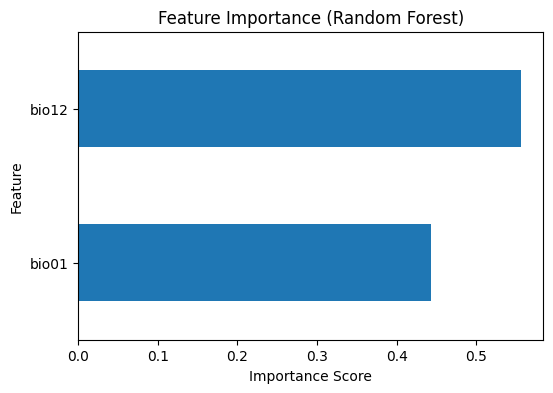

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)

plt.figure(figsize=(6,4))
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Predicted vs Actual Plot

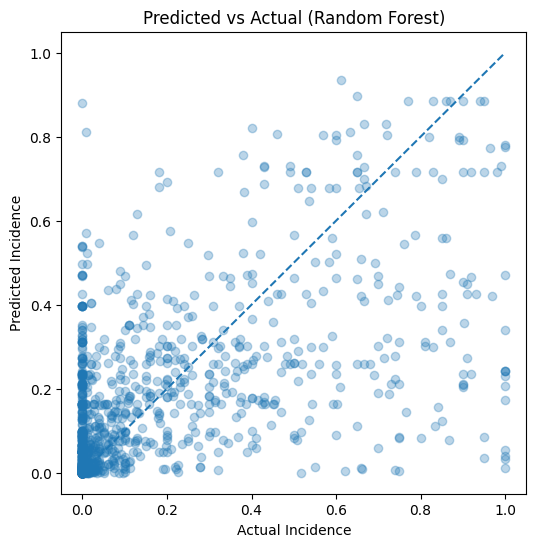

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.xlabel("Actual Incidence")
plt.ylabel("Predicted Incidence")
plt.title("Predicted vs Actual (Random Forest)")

# perfect prediction line
plt.plot([0,1], [0,1], linestyle='--')

plt.show()

Visualization

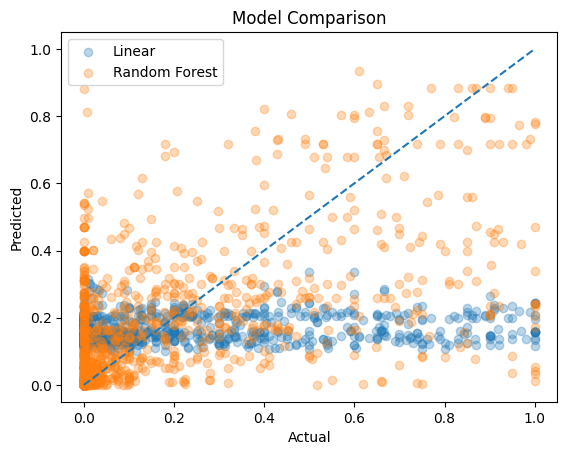

In [11]:
plt.scatter(y_test, y_pred_lr, alpha=0.3, label="Linear")
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison")

plt.show()